# Exact values

In [5]:
import scipy
from scipy.special import erf
import numpy
from numpy import exp
from numpy.lib.scimath import log, sqrt

# data
S0 = 100.
K = 100.
T = 1.
r = 0.1
sigma = 0.25
t=0

def N(x):
    return 0.5 * (1. + erf(x / sqrt(2.)))

def black_scholes(S0, K, T, r, sigma):
    d1 = 1./(sigma * sqrt(T)) * (log(S0 / K) + (r + (sigma**2) / 2.) * T)
    d2 = d1 - sigma * sqrt(T)
    C = S0 * N(d1) - K * exp(-r * T) * N(d2)
    P = S0 *(N(d1) - 1.) - K * exp(-r * T) * (N(d2)-1.)
    return C, P

if __name__ == "__main__":
    call, put = black_scholes(S0, K, T, r, sigma)
    print(" == BLACK-SCHOLES ==")
    print("call: ", call)
    print("put: ", put)

 == BLACK-SCHOLES ==
call:  14.975790778311286
put:  5.4595325819072364


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Exercise 03.1

## Direct sampling of the final asset price 

Strike price implementation:

This function provide a prevision of the asset price at time t 
following a GBM evolution with
- S0 initial asset price
- mu drift value
- sigma volatility  

```C++

double S(
	double t, 
	double S0, double mu, double sigma, 
	Random &rnd
)
{
	double W=rnd.Gauss(0, t);
	
	return S0*( exp((mu-0.5*sigma*sigma)*t + sigma*W ) ) ;
}
```

Below the code snippet to update the block average (not progressive) of strike price and call and put options

```C++
for(int block=0; block<nblock; ++block)
{
	for(int l=0; l<L; ++l)
	{
		//strike price MC
		double St=S(T, S0, r, sig, rnd);

		//compute strike price average
		avg[block]+=St;
		//compute call price average
		cal[block]+=max(0., St-K)*exp(-r*T);
		//compute put price average
		put[block]+=max(0., K-St)*exp(-r*T);
	}
	// strike price average
	avg[block]/=L;                      //normal
	av2[block]=avg[block]*avg[block];   //squared

	// call option average
	cal[block]/=L;                      //normal
	ca2[block]=cal[block]*cal[block];   //squared
    
	// put option average
	put[block]/=L;                      //normal
	pu2[block]=put[block]*put[block];   //squared

}
```



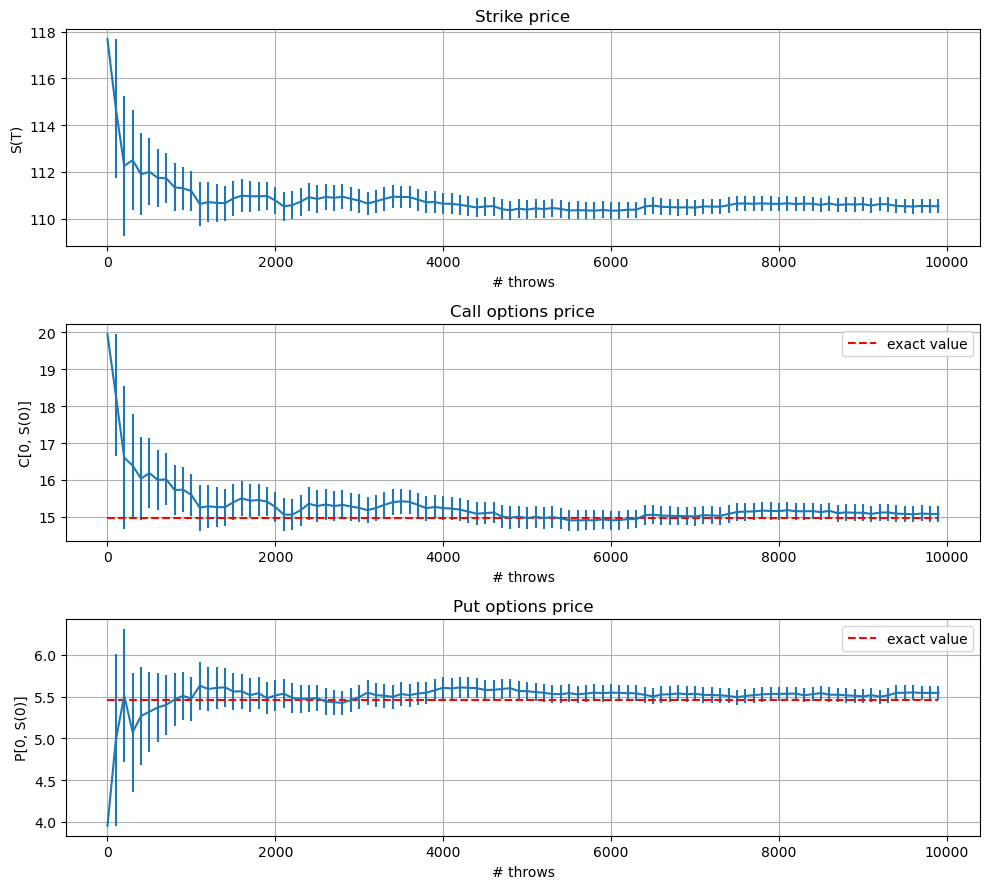

In [20]:
df=pd.read_csv('data/strike_priceT.csv')
calldf=pd.read_csv('data/call_priceT.csv')
putdf=pd.read_csv('data/put_priceT.csv')

plt.figure(figsize=(10, 9))

ax = plt.subplot(3, 1, 1)
ax.errorbar(df.throws, df.avg, yerr=df.err)
ax.grid(True)
ax.set_title('Strike price')
ax.set_xlabel('# throws')
ax.set_ylabel('S(T)')

ax = plt.subplot(3, 1, 2)

ax.errorbar(calldf.throws, calldf.avg, yerr=calldf.err)
ax.hlines(
    call, 
    0, calldf.throws[len(calldf)-1], 
    colors='r', linestyles='--',
    label='exact value'
)
ax.set_title('Call options price')
ax.set_xlabel('# throws')
ax.set_ylabel('C[0, S(0)]')
ax.grid(True)
ax.legend()

ax = plt.subplot(3, 1, 3)

ax.errorbar(putdf.throws, putdf.avg, yerr=putdf.err)
ax.hlines(
    put, 
    0, putdf.throws[len(putdf)-1], 
    colors='r', linestyles='--',
    label='exact value'
)
ax.grid(True)
ax.legend()
ax.set_title('Put options price')
ax.set_xlabel('# throws')
ax.set_ylabel('P[0, S(0)]')

plt.tight_layout()
plt.show()

## Discretized 
Strike price implementation:

This function provide a prevision of the asset price at time t 
following a GBM evolution with
- t0 precedent time value in the series
- S0 precedent asset price  at time t0
- mu drift value
- sigma volatility  

```C++
double S(
	double t, double t0,
	double S0, double mu, double sigma, 
	Random &rnd
)
{
	double Z=rnd.Gauss(0, 1);
	
	return S0*( exp((mu-0.5*sigma*sigma)
		*(t-t0) + sigma*Z*sqrt(t-t0) ) ) ;
}
```

The difference in the per-block-average computation from the previous method it's in the fact that for each realization one must compute n steps to reach the value of S(T)

```C++
for(int block=0; block<nblock; ++block)
{
	for(int l=0; l<L; ++l)
	{
		//strike price MC
		double St=S(1/n, 0., S0, r, sig, rnd);
        
		for (int i=2; i<=n; ++i) 
			St=S(i/n, (i-1)/n, St, r, sig, rnd);
		//compute strike price average
		avg[block]+=St;

		//compute call price average
		cal[block]+=max(0., St-K)*exp(-r*T);
		//compute put price average
		put[block]+=max(0., K-St)*exp(-r*T);
	}
	avg[block]/=L;
	av2[block]=avg[block]*avg[block];

	cal[block]/=L;
	ca2[block]=cal[block]*cal[block];
    
	put[block]/=L;
	pu2[block]=put[block]*put[block];
}
```

/tmp/ipykernel_7992/1745003649.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


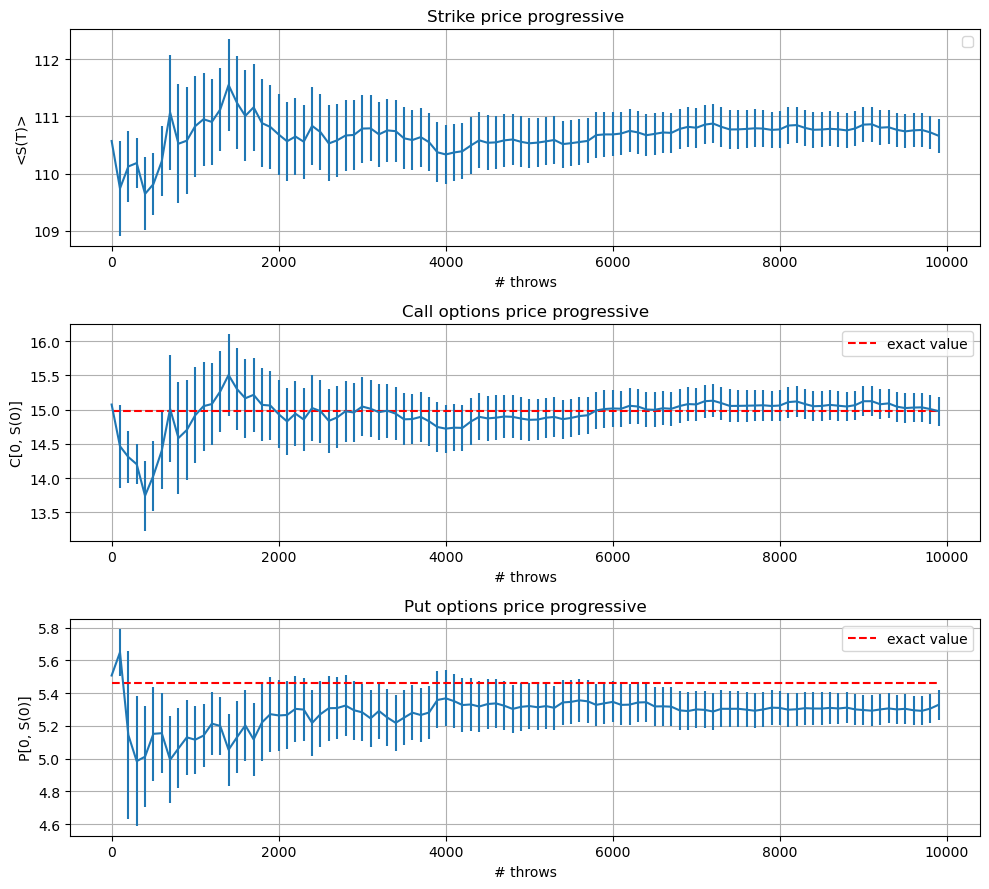

In [24]:
sp=pd.read_csv('data/strike_priceT_progressive.csv')
cp=pd.read_csv('data/call_priceT_progressive.csv')
pp=pd.read_csv('data/put_priceT_progressive.csv')

plt.figure(figsize=(10, 9))

ax = plt.subplot(3, 1, 1)

ax.errorbar(sp.throws, sp.avg, yerr=sp.err)
ax.grid(True)
ax.legend()
ax.set_title('Strike price progressive')
ax.set_xlabel('# throws')
ax.set_ylabel('<S(T)>')

ax = plt.subplot(3, 1, 2)

ax.errorbar(cp.throws, cp.avg, yerr=cp.err)
ax.hlines(
    call, 
    0, cp.throws[len(cp)-1], 
    colors='r', linestyles='--',
    label='exact value'
)
ax.grid(True)
ax.legend()
ax.set_title('Call options price progressive')
ax.set_xlabel('# throws')
ax.set_ylabel('C[0, S(0)]')

ax = plt.subplot(3, 1, 3)
ax.errorbar(pp.throws, pp.avg, yerr=pp.err)
ax.hlines(
    put, 
    0, pp.throws[len(pp)-1], 
    colors='r', linestyles='--',
    label='exact value'
)
ax.grid(True)
ax.legend()
ax.set_title('Put options price progressive')
ax.set_xlabel('# throws')
ax.set_ylabel('P[0, S(0)]')

plt.tight_layout()
plt.show()



# Comparison

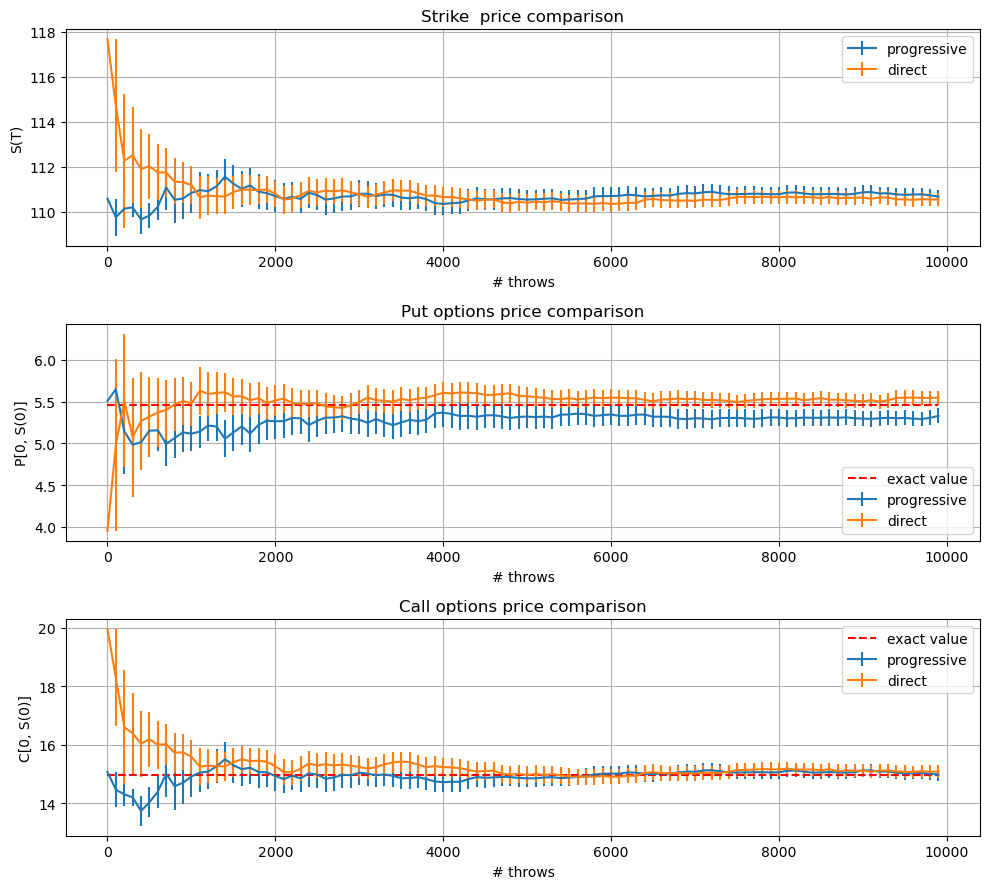

In [28]:
plt.figure(figsize=(10, 9))

ax = plt.subplot(3,1, 1)

ax.errorbar(sp.throws, sp.avg, yerr=sp.err, label='progressive')
ax.errorbar(df.throws, df.avg, yerr=df.err, label='direct')
ax.grid(True)
ax.legend()
ax.set_title('Strike  price comparison')
ax.set_xlabel('# throws')
ax.set_ylabel('S(T)')

ax = plt.subplot(3, 1, 2)

ax.errorbar(pp.throws, pp.avg, yerr=pp.err, label='progressive')
ax.errorbar(putdf.throws, putdf.avg, yerr=putdf.err, label='direct')
ax.hlines(
    put, 
    0, putdf.throws[len(putdf)-1], 
    colors='r', linestyles='--',
    label='exact value'
)
ax.grid(True)
ax.legend()
ax.set_title('Put options price comparison')
ax.set_xlabel('# throws')
ax.set_ylabel('P[0, S(0)]')

ax = plt.subplot(3,1, 3)

ax.errorbar(cp.throws, cp.avg, yerr=cp.err, label='progressive')
ax.errorbar(calldf.throws, calldf.avg, yerr=calldf.err, label='direct')
ax.hlines(
    call, 
    0, calldf.throws[len(calldf)-1], 
    colors='r', linestyles='--',
    label='exact value'
)
ax.grid(True)
ax.legend()
ax.set_title('Call options price comparison')
ax.set_xlabel('# throws')
ax.set_ylabel('C[0, S(0)]')

plt.tight_layout()
plt.show()

